# Data Driven Analytics Summative 2: Technical Implementation

## Data Acquisition and Engineering

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ulrikthygepedersen/online-retail-dataset",
    "online_retail.csv",
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Missing Values

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Missing Stock Codes

In [6]:
df.shape

(541909, 8)

In [7]:
# Count unique descriptions per StockCode
desc_counts = df.groupby("StockCode")["Description"].nunique()

# StockCodes with more than one description
multi_desc_stockcodes = desc_counts[desc_counts > 1]

# Inspect
multi_desc_stockcodes.sort_values(ascending=False).head(10)


StockCode
20713     8
23084     7
85175     6
21830     6
85172     5
21181     5
72807A    5
23131     5
23343     5
85123A    4
Name: Description, dtype: int64

In [8]:
# StockCodes with missing descriptions
missing_desc_stockcodes = df.loc[
    df["Description"].isnull(), "StockCode"
].unique()

ambiguous_stockcodes = multi_desc_stockcodes.index.intersection(
    missing_desc_stockcodes
)

print(f"Number of ambiguous StockCodes: {len(ambiguous_stockcodes)}")

Number of ambiguous StockCodes: 174


In [9]:
df[df["StockCode"].isin(ambiguous_stockcodes)][
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
103332,10080,GROOVY CACTUS INFLATABLE
454350,10080,check
279310,10080,NaN
23437,15058A,BLUE POLKADOT GARDEN PARASOL
192289,15058A,wet/rusty
...,...,...
10792,90014B,GOLD M PEARL ORBIT NECKLACE
386649,90014B,GOLD M.O.P. ORBIT NECKLACE
142063,90014C,SILVER/BLACK ORBIT NECKLACE
381682,90014C,NaN


Stock Code is complete, description is not. Null values will be filled with the appropriate description based on stock code. In stock codes where more than one description is present, the most common description is used.

In [10]:
# Create a mapping from StockCode to the most common non-null Description
stockcode_description_map = (
    df.dropna(subset=["Description"])
      .groupby("StockCode")["Description"]
      .agg(lambda x: x.mode().iloc[0])
)

df["Description"] = df["Description"].fillna(
    df["StockCode"].map(stockcode_description_map)
)

df["Description"].isnull().sum()

112

Records where no historical description existed for the StockCode were retained but flagged to preserve transaction integrity

In [11]:
df["Description"] = df["Description"].fillna("UNKNOWN_PRODUCT")
df["Description"].isnull().sum()

0

In [12]:
df.shape

(541909, 8)

An exploratory consistency check revealed that a small subset of StockCodes mapped to multiple product descriptions, indicating historical inconsistency in the source data.
For StockCodes with missing descriptions, the most frequently occurring description was used to minimise semantic ambiguity.
StockCodes with no historical descriptions were retained and flagged as unknown to preserve transactional integrity.

#### Missing CustomerID

There are 135080 missing customerID rows. It is not feasible to simply drop these rows without losing large amounts of information, inputting random values would destroy the churn analysis and using mean values would not make sense. Because CustomerID is assigned at the invoicelevel and each invoice can span multiple rows, we can attempt to recover missing CustomerIDs by looking at other rows with the same InvoiceNo.

In [13]:
# Build a mapping: InvoiceNo → CustomerID
invoice_customer_map = (
    df.dropna(subset=["CustomerID"])
      .groupby("InvoiceNo")["CustomerID"]
      .agg(lambda x: x.mode().iloc[0])
)

df["CustomerID"] = df["CustomerID"].fillna(
    df["InvoiceNo"].map(invoice_customer_map)
)

df["CustomerID"].isnull().sum()

135080

You attempted recovery using key‑based logic
You validated whether recovery was possible
You concluded (correctly) that it was not feasible without inventing data. 

To preserve the data, these rows will be kept. It was considered to fill these rows with "Guest User" however this would impact the datatype of the column and could cause issues later in the pipeline. I also considered filling with -1, this would preserve the datatype, but could cause issues in any aggregation.

As such, it is best to leave these values as null and create a binary customer type flag where 1 represents a registered customer and 0 represents a guest user. This allows the full dataset to be used for transaction modelling, but excludes these null values from customer churn modelling, preserving quality.

Using 0 and 1 (and creating this flag variable), is more suitable as this is a modelling workbook. This removes the need to encode this column later.

In [14]:
#df["CustomerID"] = df["CustomerID"].fillna("Guest User")
#df["CustomerID"].isnull().sum()

In [15]:
import numpy as np

df["CustomerTypeFlag"] = np.where(
    df["CustomerID"].isna(),
    0,
    1
)

In [16]:
df["CustomerTypeFlag"].value_counts()

CustomerTypeFlag
1    406829
0    135080
Name: count, dtype: int64

In [17]:
df.shape

(541909, 9)

### Duplicated Values

In [18]:
df.duplicated(subset=None).sum()

5268

In [19]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,1
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,1
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,1
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,1


In [20]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,1
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,1
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom,1
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,1
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,1
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom,1


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.shape

(536641, 9)

Duplicate rows were examined and as they were shown to be exact matches were removed. As a customer can have a quantity of more than 1, it suggests that these rows are errors rather than legitimate orders, as such they have been dropped from the dataset.

### Semantic Validation

#### Negative Values

Negative values should not appear in the unit price column. This column is examined and negative values are removed. (Quantities can be negative as they represent returned products). The data is only filtered to show rows where the value is less than 0, this allows for the valid 'sales' of free gifts.

In [23]:
negatives = df[df['UnitPrice']<0]
negatives.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,0
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,0


In [24]:
df = df[~df.index.isin(negatives.index)]
df.shape

(536639, 9)

#### Logic Errors

In the following code, any impossible rows are removed. I.e where their 

In [25]:
invoice_customer_check = (
    df.groupby("InvoiceNo")["CustomerID"]
      .nunique()
)

invoice_customer_check[invoice_customer_check > 1]

Series([], Name: CustomerID, dtype: int64)

No rows were found here, meaning that every row on an invoice is aligned to the same customer.

In [26]:
invoice_date_check = (
    df.groupby("InvoiceNo")["InvoiceDate"]
      .nunique()
)

invoice_date_check[invoice_date_check > 1]

InvoiceNo
536591     2
540185     2
541596     2
541631     2
541809     2
541816     2
541849     2
542217     2
542806     2
543171     2
543179     2
543182     2
543777     2
544186     2
544667     2
544926     2
545460     2
545713     2
546388     2
546986     2
547690     2
548203     2
549245     2
549524     2
550320     2
550333     2
550641     2
550645     2
552000     2
553199     2
553375     2
553556     2
554116     2
558086     2
561369     2
562128     2
563245     2
567183     2
571735     2
574076     2
576057     2
578548     2
C545569    2
Name: InvoiceDate, dtype: int64

In [27]:
len(invoice_date_check[invoice_date_check > 1])

43

43 invoices contain multiple timestamps, in the next code block one of these invoices is investigated. Please note other invoices were checked to ensure the error is consistent, but these are not included in the final notebook for conciseness.

In [28]:
df.loc[df["InvoiceNo"] == "536591"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
2421,536591,21427,SKULLS STORAGE BOX SMALL,1,2010-12-01 16:57:00,2.10,14606.0,United Kingdom,1
2422,536591,22135,LADLE LOVE HEART PINK,1,2010-12-01 16:57:00,0.42,14606.0,United Kingdom,1
2423,536591,90214M,"LETTER ""M"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2424,536591,90214V,"LETTER ""V"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2425,536591,90214S,"LETTER ""S"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2426,536591,90214J,"LETTER ""J"" BLING KEY RING",2,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2427,536591,22386,JUMBO BAG PINK POLKADOT,1,2010-12-01 16:57:00,1.95,14606.0,United Kingdom,1
2428,536591,22378,WALL TIDY RETROSPOT,1,2010-12-01 16:57:00,2.10,14606.0,United Kingdom,1
2429,536591,20750,RED RETROSPOT MINI CASES,1,2010-12-01 16:57:00,7.95,14606.0,United Kingdom,1
2430,536591,21888,BINGO SET,1,2010-12-01 16:57:00,3.75,14606.0,United Kingdom,1


Examining the first example of where an invoice has two time stamps shows that they are consequetive minutes. This suggests that the orginal orders database is updated in batches, e.g. per 100 rows. This has revealed something that is mathematically an error, but represents real-world systems. While the data could be left as is for this project, I am choosing to remove any inconsistencies with the data and set each invoice date to its earliest occurence, representing the start of the transaction and preserving chronological order.

In [29]:
invoice_dates = df.groupby("InvoiceNo")["InvoiceDate"].min()
df.loc[:, "InvoiceDate"] = df["InvoiceNo"].map(invoice_dates)

In [30]:
invoice_date_check = (
    df.groupby("InvoiceNo")["InvoiceDate"]
      .nunique()
)

invoice_date_check[invoice_date_check > 1]

Series([], Name: InvoiceDate, dtype: int64)

Running the earlier check again shows that all invoices are associated with a single timestamp.

##### Pricing Inconsistencies

In [31]:
price_variation = df.groupby("StockCode")["UnitPrice"].nunique()
price_variation.sort_values(ascending=False).head()


StockCode
DOT     687
M       260
POST    114
D        75
S        59
Name: UnitPrice, dtype: int64

In [32]:
df.loc[df["StockCode"] == "DOT"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
1814,536544,DOT,DOTCOM POSTAGE,1,2010-12-01 14:32:00,569.77,NaN,United Kingdom,0


In [33]:
df.loc[df["StockCode"] == "M"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom,1


In [34]:
df.loc[df["StockCode"] == "POST"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.0,12583.0,France,1


In [35]:
df.loc[df["StockCode"] == "D"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.5,14527.0,United Kingdom,1


In [36]:
df.loc[df["StockCode"] == "S"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
14436,C537581,S,SAMPLES,-1,2010-12-07 12:03:00,12.95,NaN,United Kingdom,0


DOT and POST stock codes represent postage, so will not be amended as postage cost will vary based on the items being shipped (weight, size & destination dependent).

The other stock codes represent discounts or free samples or other manual adjustments. With the absence of any additional context surrounding individual orders, no changes will be made to the dataframe

##### Geographic Inconsistencies

In the code below customers are verified to ensure that customers are not associated with more than one country. As there are only a couple of customers, this suggests that they are multinational companies, these rows are not errors so will not be modified.

In [37]:
df.groupby("CustomerID")["Country"].nunique().loc[lambda x: x > 1]

CustomerID
12370.0    2
12394.0    2
12417.0    2
12422.0    2
12429.0    2
12431.0    2
12455.0    2
12457.0    2
Name: Country, dtype: int64

In [38]:
import pandas as pd

# Calculating the interquartile range and the upper and lower bound for the duration
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print("Quantity upper bound is:", upper_bound, "and the lower bound is", lower_bound)

# Calculating the number of trips outside of the upper and lower bounds
mask = (df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)
print(mask.value_counts())

# Removing outlier rows
df = df[~mask]

# Validating the new shape of the dataframe
df.shape

Quantity upper bound is: 23.5 and the lower bound is -12.5
Quantity
False    478138
True      58501
Name: count, dtype: int64


(478138, 9)

In [39]:
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print("UnitPrice upper bound is:", upper_bound, "and the lower bound is", lower_bound)

# Calculating the number of trips outside of the upper and lower bounds
mask = (df['UnitPrice'] < lower_bound) | (df['UnitPrice'] > upper_bound)
print(mask.value_counts())

UnitPrice upper bound is: 8.649999999999999 and the lower bound is -3.1899999999999995
UnitPrice
False    445792
True      32346
Name: count, dtype: int64


Considering that some of the postage costs are higher than the upper bound, it is not realistic to remove the rows with the higher prices without losing higher ticket orders. We already know that there are no rows with negative pricing, so no changes are made here.

In [40]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1


In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(list(df['Country'].values))

df['Country_num'] = le.transform(list(df['Country'].values))
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag,Country_num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,36
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,36
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36


While the Description column could be encoded as it could be classed as a categorical variable, I will not be doing so as it would be redudant, earlier cleansing steps made the stock code column and description column equivalent. As there are 478138 unique descriptions, encoding this variable would be overfitting and would slow down the model, making it inefficient.

In [42]:
df['Description'].value_counts().sum()

478138

In [43]:
non_numeric_mask = ~df["StockCode"].astype(str).str.isnumeric()
alpha_mask = df["StockCode"].astype(str).str.isalpha()
non_numeric_mask.sum()
#alpha_mask.sum()


49003

There are 49003 rows where the stock code contains a non-numeric character. We know from earlier explorations this could be items like postage or discount, however there are also valid product codes like 85123A (a white hanging heart t-light holder). While not a perfect solution, an alternate dataset containing only numeric product codes will be created for modelling. This allows for a full dataset retaining these rows to be used for some forms of analysis and EDA, but will not produce errors when modelling as the alternate dataset will be used.

In [44]:
numeric_df = df[~non_numeric_mask]
numeric_df.shape


(429135, 10)

### Creating a customer dataset

In [45]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df_customers = df[df["CustomerTypeFlag"] == 1].copy()

In [46]:
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag,Country_num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,36
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,36
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36


In [47]:
df_customers["Revenue"] = df_customers["Quantity"] * df_customers["UnitPrice"]

In [48]:
customer_df = df_customers.groupby("CustomerID").agg({
    "InvoiceDate": ["min", "max"],
    "InvoiceNo": "nunique",
    "Revenue": ["sum", "mean", "max"],
    "StockCode": "nunique"
})

In [49]:
customer_df.columns = [
    "FirstPurchase",
    "LastPurchase",
    "TotalNoOfOrders",
    "TotalSpend",
    "AvgSpend",
    "MaxSpend",
    "NoOfUniqueProducts"
]


In [50]:
reference_date = df["InvoiceDate"].max()

customer_df["DaysSinceLastPurchase"] = (reference_date - customer_df["LastPurchase"]).dt.days

In [51]:
customer_df.head()

,FirstPurchase,LastPurchase,TotalNoOfOrders,TotalSpend,AvgSpend,MaxSpend,NoOfUniqueProducts,DaysSinceLastPurchase
CustomerID,,,,,,,,
12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,3097.82,21.073605,97.8,90,1
12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,377.00,75.400000,240.0,2,74
12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1626.15,23.913971,300.0,68,18
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,314.00,19.625000,40.0,16,309
12352.0,2011-02-16 12:33:00,2011-11-03 14:37:00,11,1545.41,16.267474,376.5,59,35


In [52]:
customer_df = customer_df[['FirstPurchase', 'LastPurchase', 'DaysSinceLastPurchase', 'TotalNoOfOrders', 'TotalSpend', 'AvgSpend', 'MaxSpend', 'NoOfUniqueProducts']]

In [53]:
customer_df = customer_df.reset_index()

In [54]:
customer_df.head()

,CustomerID,FirstPurchase,LastPurchase,DaysSinceLastPurchase,TotalNoOfOrders,TotalSpend,AvgSpend,MaxSpend,NoOfUniqueProducts
0,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,1,7,3097.82,21.073605,97.8,90
1,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,74,4,377.00,75.400000,240.0,2
2,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,18,1,1626.15,23.913971,300.0,68
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,309,1,314.00,19.625000,40.0,16
4,12352.0,2011-02-16 12:33:00,2011-11-03 14:37:00,35,11,1545.41,16.267474,376.5,59


#### Scaling Customer Dataframe and PCA

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

structured_cols = ["DaysSinceLastPurchase", "TotalNoOfOrders", "TotalSpend", "AvgSpend", "MaxSpend", "NoOfUniqueProducts"]
df_structured = customer_df[structured_cols]
df_encoded = pd.get_dummies(df_structured, drop_first=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

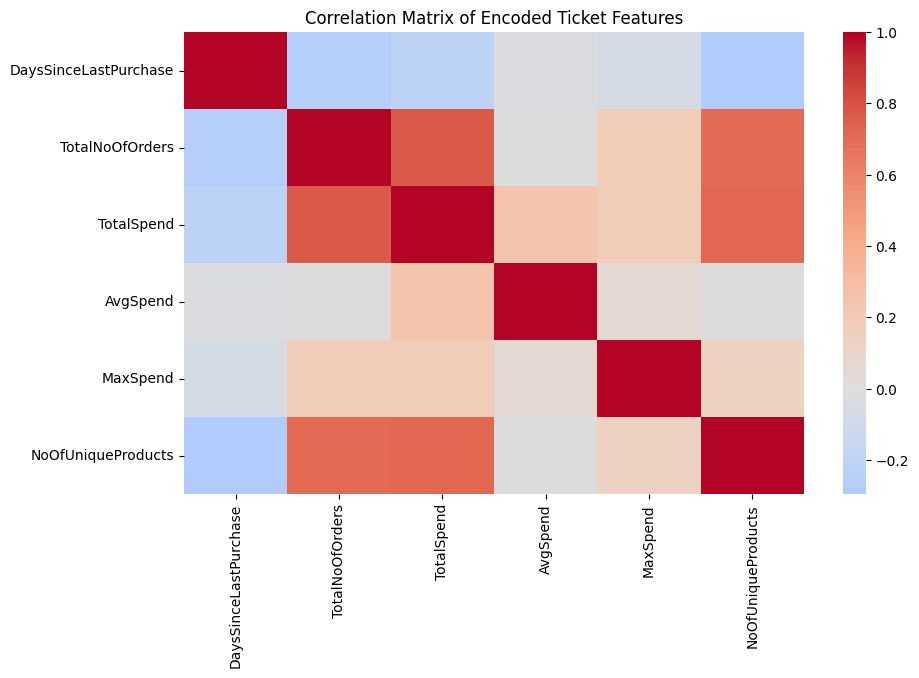

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a correlation matrix for the encoded features
corr_matrix = df_encoded.corr()

# Correlation heatmap visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Encoded Ticket Features")
plt.show()


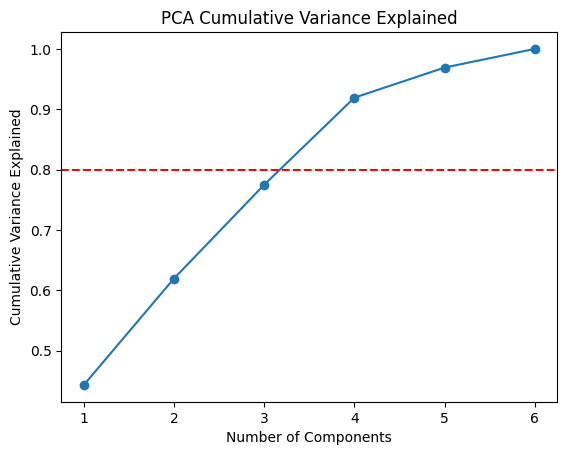

In [57]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Extracting the explained variance ratio for each principal component
explained_variance = pca.explained_variance_ratio_

# Creating a DataFrame to display the variance explained by each principal component
variance_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Variance Explained": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

# Visualising the cumulative variance explained by the principal components to determine how many components to retain
plt.plot(variance_df["Component"], variance_df["Cumulative Variance"], marker="o")
plt.axhline(0.8, linestyle="--", color="red")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Cumulative Variance Explained")
plt.show()

In [58]:
n_components = variance_df[variance_df["Cumulative Variance"] <= 0.8].shape[0]
X_reduced = X_pca[:, :n_components]

In [59]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df_encoded.columns,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)

loadings

,DaysSinceLastPurchase,TotalNoOfOrders,TotalSpend,AvgSpend,MaxSpend,NoOfUniqueProducts
PC1,-0.261272,0.544171,0.553656,0.097508,0.187784,0.533206
PC2,0.262176,-0.124180,0.149297,0.877267,0.308851,-0.169020
PC3,0.196885,0.013001,-0.105395,-0.367330,0.900957,-0.057481
PC4,0.904177,0.201700,0.194934,-0.163683,-0.235021,0.147492
PC5,0.063437,-0.599005,-0.157896,0.056000,0.048837,0.778920
PC6,-0.051731,-0.537399,0.772746,-0.236719,-0.002067,-0.235264


## Exploratory Data Analysis (EDA)

#### Exploration 1: Customer Types

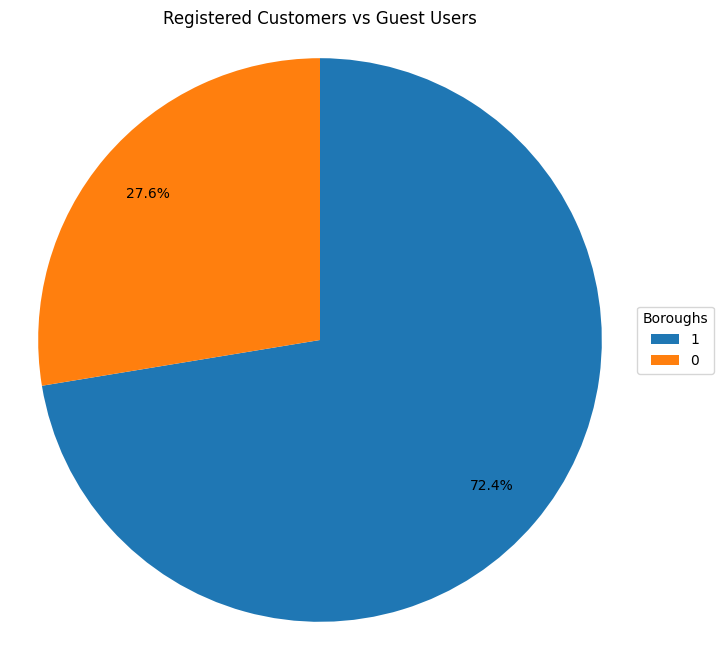

In [62]:
# Calculating counts
counts = df["CustomerTypeFlag"].value_counts()

# Generating pie chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(
    counts,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.8
)

# Show chart
ax.set_title("Registered Customers vs Guest Users")
ax.legend(wedges, counts.index, title="Boroughs", loc="center left", bbox_to_anchor=(1,0.5))
ax.axis("equal")
plt.show()

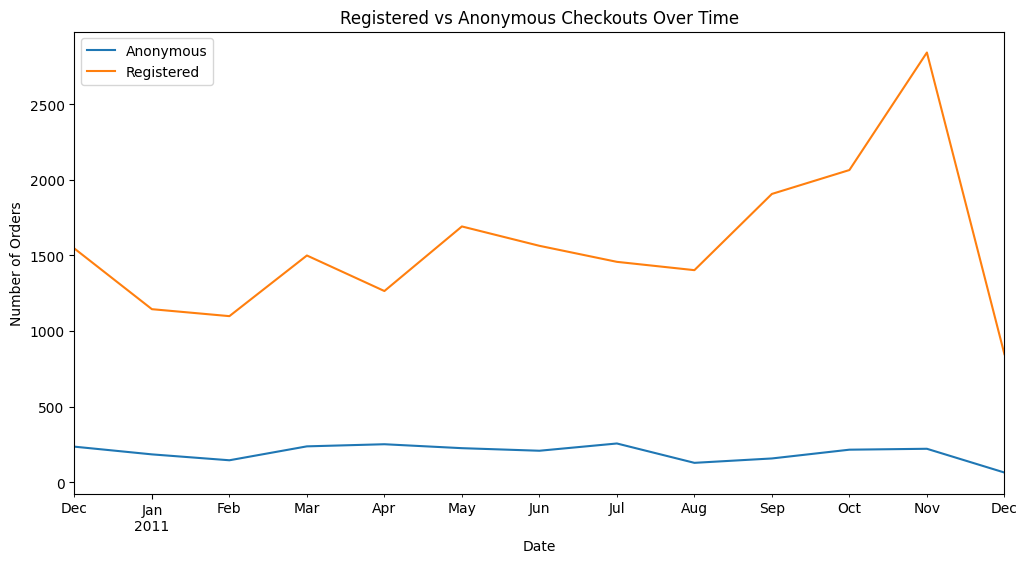

In [94]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

checkout_trends = df.groupby(
    ["YearMonth", "CustomerTypeFlag"]
)["InvoiceNo"].nunique().reset_index()

checkout_trends = checkout_trends.pivot(
    index="YearMonth",
    columns="CustomerTypeFlag",
    values="InvoiceNo"
)

checkout_trends.columns = ["Anonymous", "Registered"]

checkout_trends.index = checkout_trends.index.to_timestamp()

checkout_trends.plot(figsize=(12,6))

plt.title("Registered vs Anonymous Checkouts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()


#### Exploration 2: Churn Indicators

<Axes: xlabel='DaysSinceLastPurchase', ylabel='Count'>

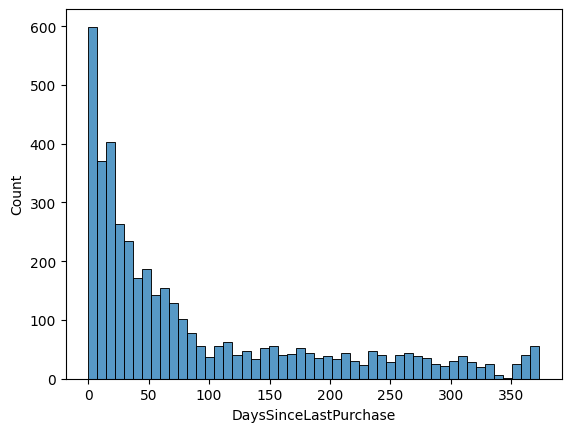

In [64]:
sns.histplot(customer_df["DaysSinceLastPurchase"], bins=50)

In [96]:
customer_df['DaysSinceLastPurchase'].describe()

count    4255.000000
mean       91.545711
std       100.733073
min         0.000000
25%        16.000000
50%        49.000000
75%       144.000000
max       373.000000
Name: DaysSinceLastPurchase, dtype: float64

In [117]:
customer_df["DaysSinceLastPurchase"].quantile(0.65)

84.0

In [119]:
customer_df["DaysSinceLastPurchase"].quantile(0.71)

116.0

In [120]:
def customer_health(recency):
    if recency <= customer_df["DaysSinceLastPurchase"].quantile(0.65):
        return "Active"
    elif recency <= customer_df["DaysSinceLastPurchase"].quantile(0.71):
        return "Churn Risk"
    else:
        return "Churned"

customer_df["CustomerHealth"] = customer_df["DaysSinceLastPurchase"].apply(customer_health)

<Axes: xlabel='TotalNoOfOrders', ylabel='TotalSpend'>

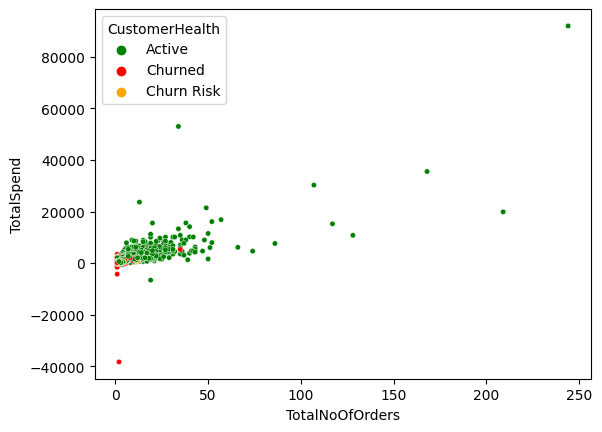

In [122]:
import seaborn as sns

palette = {
    "Active": "green",
    "Churn Risk": "orange",
    "Churned": "red"
}

sns.scatterplot(
    data=customer_df,
    x="TotalNoOfOrders",
    y="TotalSpend",
    hue="CustomerHealth",
    s = 15,
    palette=palette
)

In [ ]:
import plotly.express as px

# Create list of customers and monthly timeline
customers = df["CustomerID"].dropna().unique()

months = pd.date_range(
    df["InvoiceDate"].min(),
    df["InvoiceDate"].max(),
    freq="MS"
)

# Create a grid of customers x months
grid = pd.MultiIndex.from_product(
    [customers, months],
    names=["CustomerID", "YearMonth"]
).to_frame(index=False)

df_sorted = df.sort_values(["CustomerID", "InvoiceDate"])

# Merge grid with purchase data
merged = grid.merge(
    df_sorted[["CustomerID", "InvoiceDate"]],
    on="CustomerID",
    how="left"
)

# Get last purchase before each month
last_purchase = merged.groupby(
    ["CustomerID", "YearMonth"]
)["InvoiceDate"].max().reset_index()

# Compute recency
last_purchase["Recency"] = (
    last_purchase["YearMonth"] - last_purchase["InvoiceDate"]
).dt.days

# Get first purchase date per customer
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min().reset_index()
first_purchase.columns = ["CustomerID", "FirstPurchaseDate"]

# Merge into last_purchase
last_purchase = last_purchase.merge(
    first_purchase,
    on="CustomerID",
    how="left"
)

# Remove months before first purchase
last_purchase = last_purchase[
    last_purchase["YearMonth"] >= last_purchase["FirstPurchaseDate"]
]

# Apply health segmentation
last_purchase["CustomerHealth"] = last_purchase["Recency"].apply(customer_health)


# Aggregate counts for plotting
health_counts = last_purchase.groupby(
    ["YearMonth", "CustomerHealth"]
).size().reset_index(name="Count")


# Fix missing combinations
health_counts = health_counts.pivot(
    index="YearMonth",
    columns="CustomerHealth",
    values="Count"
).fillna(0).reset_index()

health_counts = health_counts.melt(
    id_vars="YearMonth",
    var_name="CustomerHealth",
    value_name="Count"
)

# Plot interactive bar chart
fig = px.bar(
    health_counts,
    x="CustomerHealth",
    y="Count",
    color="CustomerHealth",
    animation_frame="YearMonth",
    category_orders={
        "CustomerHealth": ["Active", "Churn Risk", "Churned"]
    },
    color_discrete_map={
        "Active": "green",
        "Churn Risk": "orange",
        "Churned": "red"
    },
    title="Customer Health Over Time (Dynamic Churn Model)"
)

fig.update_layout(
    yaxis=dict(range=[0, health_counts["Count"].max()])
)

fig.show()

#### Exploration 3: 

<Axes: xlabel='TotalSpend', ylabel='Count'>

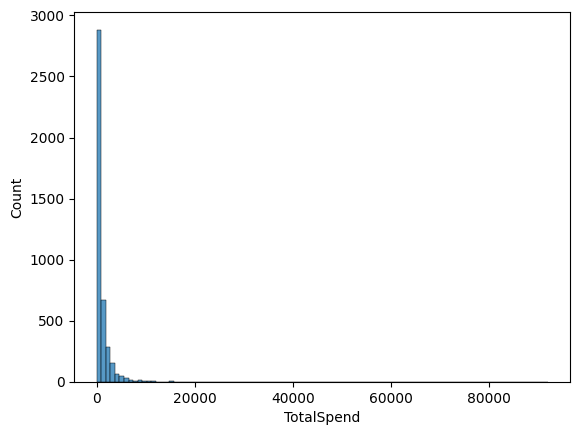

In [89]:
#sns.histplot([customer_df["TotalSpend"]], bins=100)
sns.histplot(customer_df[customer_df["TotalSpend"] > 0]["TotalSpend"], bins=100)

#### Exploration 4: Order Quantities

<Axes: xlabel='Quantity', ylabel='Count'>

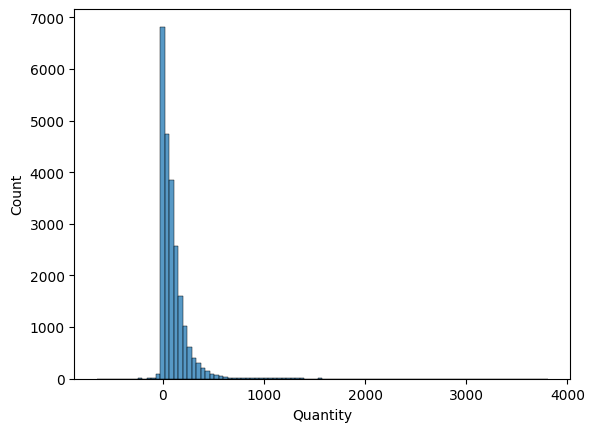

In [92]:
order_items = df.groupby("InvoiceNo")["Quantity"].sum()
sns.histplot(order_items, bins=100)

<Axes: xlabel='Description'>

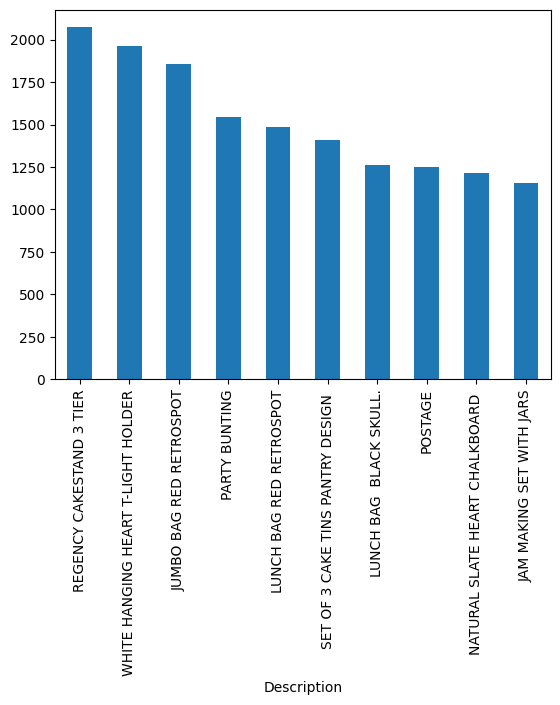

In [83]:
df["Description"].value_counts().head(10).plot(kind="bar")

In [132]:
df["IsReturn"] = df["Quantity"] < 0
product_returns = df.groupby(["Description", "IsReturn"])["Quantity"].sum().unstack()

product_returns["Returns"] = product_returns[True].abs()
product_returns["Kept"] = product_returns[False]
product_returns["ReturnRate"] = product_returns["Returns"] / (product_returns["Returns"] + product_returns["Kept"])


product_returns = product_returns[["ReturnRate"]]

top_products = product_returns.sort_values("ReturnRate", ascending=False).head(10)

product_returns


IsReturn,ReturnRate
Description,
4 PURPLE FLOCK DINNER CANDLES,NaN
50'S CHRISTMAS GIFT BAG LARGE,0.001676
DOLLY GIRL BEAKER,0.007277
I LOVE LONDON MINI BACKPACK,NaN
I LOVE LONDON MINI RUCKSACK,NaN
...,...
sold as set on dotcom,NaN
taig adjust,NaN
test,NaN


In [ ]:
top_products.plot(kind="bar", figsize=(12,6))

plt.title("Most Returned vs Kept Products")
plt.ylabel("Quantity")
plt.xticks(rotation=90)
plt.show()

In [ ]:
churned_df = df.merge(
    customer_df[["CustomerID", "CustomerHealth"]],
    on="CustomerID",
    how="left"
)

churned_df = churned_df[churned_df["CustomerHealth"] == "Churned"]

churned_products = churned_df.groupby(["StockCode", "IsReturn"])["Quantity"].sum().unstack()

churned_products["Returns"] = churned_products[True].abs()
churned_products["Kept"] = churned_products[False]

churned_products = churned_products[["Kept", "Returns"]]

top_churned_products = churned_products.sort_values("Returns", ascending=False).head(10)

top_churned_products.plot(kind="bar", figsize=(12,6), color=["green", "red"])

plt.title("Products Most Returned by Churned Customers")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.show()